<a href="https://colab.research.google.com/github/imsumedhaa/fireducks-vs-pandas-EDA/blob/main/EDA_%26_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
#  Install FireDucks
!pip install fireducks

# ✅ Set environment variable correctly for Benchmark Mode
import os
os.environ["FIREDUCKS_FLAGS"] = "--benchmark-mode"

# Imports
import pandas as pd
import fireducks.pandas as fd
import numpy as np
import time
import matplotlib.pyplot as plt

# 🧪 Generate large synthetic dataset (1M rows)
df = pd.DataFrame({
    "product": np.random.choice(["apple", "banana", "orange", "kiwi"], size=1_000_000),
    "region": np.random.choice(["north", "south", "east", "west"], size=1_000_000),
    "price": np.random.uniform(10, 200, size=1_000_000),
    "units_sold": np.random.randint(1, 100, size=1_000_000)
})
df.to_csv("sales_data.csv", index=False)
print("✅ Created 'sales_data.csv'")


✅ Created 'sales_data.csv'


In [10]:
#  Read CSV
start = time.time()
pandas_df = pd.read_csv("sales_data.csv")
pandas_read_time = (time.time() - start) * 1000  # ms
print("📄 Pandas Read Time:", round(pandas_read_time, 2), "ms")

start = time.time()
fd_df = fd.read_csv("sales_data.csv")
fd_read_time = (time.time() - start) * 1000  # ms
print("🔥 FireDucks Read Time:", round(fd_read_time, 2), "ms")

📄 Pandas Read Time: 392.64 ms
🔥 FireDucks Read Time: 47.2 ms


In [9]:
#  Filter: price > 100
start = time.time()
pandas_filtered = pandas_df[pandas_df['price'] > 100]
pandas_filter_time = (time.time() - start) * 1000
print("📉 Pandas Filter Time:", round(pandas_filter_time, 2), "ms")

start = time.time()
fd_filtered = fd_df[fd_df['price'] > 100]
fd_filter_time = (time.time() - start) * 1000
print("🔥 FireDucks Filter Time:", round(fd_filter_time, 2), "ms")

📉 Pandas Filter Time: 21.16 ms
🔥 FireDucks Filter Time: 14.3 ms


In [6]:
#  Group by region, compute mean units_sold
start = time.time()
pandas_grouped = pandas_df.groupby('region')['units_sold'].mean().reset_index()
pandas_groupby_time = (time.time() - start) * 1000
print("📊 Pandas GroupBy Time:", round(pandas_groupby_time, 2), "ms")

start = time.time()
fd_grouped = fd_df.groupby('region')['units_sold'].mean().reset_index()
fd_groupby_time = (time.time() - start) * 1000
print("🔥 FireDucks GroupBy Time:", round(fd_groupby_time, 2), "ms")

📊 Pandas GroupBy Time: 66.76 ms
🔥 FireDucks GroupBy Time: 13.36 ms


In [7]:
#  Sort by units_sold descending
start = time.time()
pandas_sorted = pandas_df.sort_values(by='units_sold', ascending=False)
pandas_sort_time = (time.time() - start) * 1000
print("🔽 Pandas Sort Time:", round(pandas_sort_time, 2), "ms")

start = time.time()
fd_sorted = fd_df.sort_values(by='units_sold', ascending=False)
fd_sort_time = (time.time() - start) * 1000
print("🔥 FireDucks Sort Time:", round(fd_sort_time, 2), "ms")

🔽 Pandas Sort Time: 107.36 ms
🔥 FireDucks Sort Time: 60.01 ms


<ipython-input-8-3ba569731517>:33: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


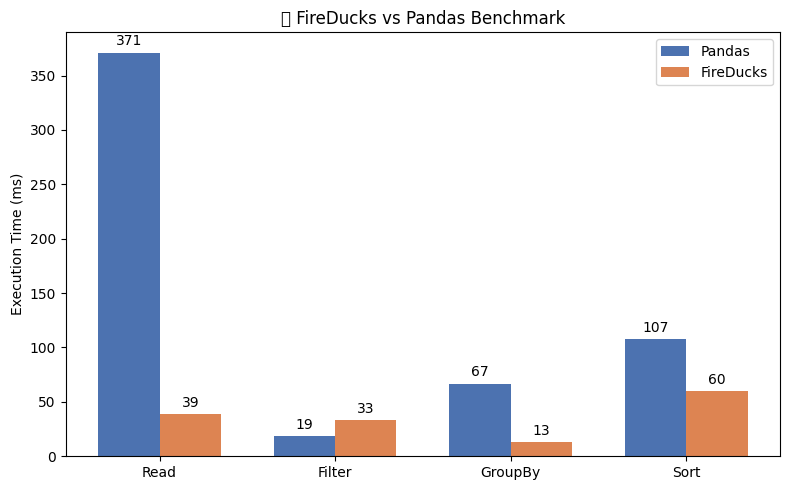

✅ Benchmark Completed


In [8]:
#  Bar chart comparing performance
import matplotlib.pyplot as plt

operations = ["Read", "Filter", "GroupBy", "Sort"]
pandas_times = [pandas_read_time, pandas_filter_time, pandas_groupby_time, pandas_sort_time]
fireducks_times = [fd_read_time, fd_filter_time, fd_groupby_time, fd_sort_time]

x = np.arange(len(operations))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, pandas_times, width, label='Pandas', color='#4c72b0')
rects2 = ax.bar(x + width/2, fireducks_times, width, label='FireDucks', color='#dd8452')

ax.set_ylabel('Execution Time (ms)')
ax.set_title('🔥 FireDucks vs Pandas Benchmark')
ax.set_xticks(x)
ax.set_xticklabels(operations)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.0f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

print("✅ Benchmark Completed")